
# Spatial correlation of errors

Digital elevation models have errors that are spatially correlated due to instrument or processing effects. Here, we
rely on a non-stationary spatial statistics framework to estimate and model spatial correlations in elevation error.
We use a sum of variogram forms to model this correlation, with stable terrain as an error proxy for moving terrain.

**References:** [Rolstad et al. (2009)](http://dx.doi.org/10.3189/002214309789470950), [Hugonnet et al. (2022)](https://doi.org/10.1109/jstars.2022.3188922).


In [1]:
import geoutils as gu

import xdem

We load a difference of DEMs at Longyearbyen, already coregistered using `nuthkaab` as shown in
the `sphx_glr_basic_examples_plot_nuth_kaab.py` example. We also load the glacier outlines here corresponding to
moving terrain.



In [2]:
dh = xdem.DEM(xdem.examples.get_path("longyearbyen_ddem"))
glacier_outlines = gu.Vector(xdem.examples.get_path("longyearbyen_glacier_outlines"))

/home/cogier/miniconda3/envs/xdem/lib/python3.12/site-packages/pyogrio/raw.py:194: RuntimeWarning: /home/cogier/miniconda3/envs/xdem/lib/python3.12/site-packages/examples/data/Longyearbyen/data/glacier_mask/CryoClim_GAO_SJ_1990.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  result = ogr_read(


Then, we run the pipeline for inference of elevation heteroscedasticity from stable terrain (*Note: we pass a*
``random_state`` *argument to ensure a fixed, reproducible random subsampling in this example*). We ask for a fit with
a Gaussian model for short range (as it is passed first), and Spherical for long range (as it is passed second):



In [3]:
(
    df_empirical_variogram,
    df_model_params,
    spatial_corr_function,
) = xdem.spatialstats.infer_spatial_correlation_from_stable(
    dvalues=dh, list_models=["Gaussian", "Spherical"], unstable_mask=glacier_outlines, random_state=42
)

/home/cogier/miniconda3/envs/xdem/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


The first output corresponds to the dataframe of the empirical variogram, by default estimated using Dowd's estimator
and a circular sampling scheme in SciKit-GStat (following Fig. S13 of Hugonnet et al. (2022)). The
``lags`` columns is the upper bound of spatial lag bins (lower bound of first bin being 0), the ``exp`` column is the
"experimental" variance value of the variogram in that bin, the ``count`` the number of pairwise samples, and
``err_exp`` the 1-sigma error of the "experimental" variance, if more than one variogram is estimated with the
``n_variograms`` parameter.



In [4]:
df_empirical_variogram

,exp,lags,count,err_exp
0,1.606022,28.284271,19,NaN
1,4.790244,40.000000,27,NaN
2,7.876436,56.568542,31,NaN
3,3.797114,80.000000,71,NaN
4,5.967543,113.137085,179,NaN
5,5.773913,160.000000,351,NaN
6,5.820014,226.274170,649,NaN
7,5.482665,320.000000,1302,NaN
8,5.874098,452.548340,2668,NaN
9,5.709442,640.000000,5188,NaN


The second output is the dataframe of optimized model parameters (``range``, ``sill``, and possibly ``smoothness``)
for a sum of gaussian and spherical models:



In [5]:
df_model_params

,model,range,psill
0,gaussian,66.369687,5.755225
0,spherical,28963.093757,1.733584


The third output is the spatial correlation function with spatial lags, derived from the variogram:



In [6]:
for spatial_lag in [0, 100, 1000, 10000, 30000]:
    print(
        "Errors are correlated at {:.1f}% for a {:,.0f} m spatial lag".format(
            spatial_corr_function(spatial_lag) * 100, spatial_lag
        )
    )

Errors are correlated at 100.0% for a 0 m spatial lag
Errors are correlated at 23.0% for a 100 m spatial lag
Errors are correlated at 22.0% for a 1,000 m spatial lag
Errors are correlated at 11.6% for a 10,000 m spatial lag
Errors are correlated at 0.0% for a 30,000 m spatial lag


We can plot the empirical variogram and its model on a non-linear X-axis to identify the multi-scale correlations.



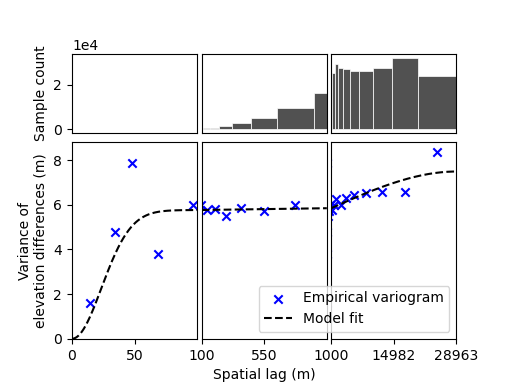

In [7]:
xdem.spatialstats.plot_variogram(
    df=df_empirical_variogram,
    list_fit_fun=[xdem.spatialstats.get_variogram_model_func(df_model_params)],
    xlabel="Spatial lag (m)",
    ylabel="Variance of\nelevation differences (m)",
    xscale_range_split=[100, 1000],
)

This pipeline will not always work optimally with default parameters: variogram sampling is more robust with a lot of
samples but takes long computing times, and the fitting might require multiple tries for forms and possibly bounds
and first guesses to help the least-squares optimization. **To learn how to tune more parameters and use the
subfunctions, see the gallery example:** `sphx_glr_advanced_examples_plot_variogram_estimation_modelling.py`!

